In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Loading dataset

dataset = pd.read_csv("CreditCardData.csv")

# Now extracting the data
dataset.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [3]:
# As from Above We can see that amount is representing Amount in £ so Now we will replce £ sign from each value
# and place it with column name so that the user can easily understand that amounts are in £ and convert it to
# Numeric Data type
dataset["Amount"] = dataset["Amount"].str.replace("£"," ")
dataset.rename(columns={"Amount":"Amount (£)"},inplace=True)
dataset["Amount (£)"] = pd.to_numeric(dataset["Amount (£)"])

dataset.head()


,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount (£),Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,5.0,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,288.0,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,5.0,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,28.0,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,91.0,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [4]:
def About_Data(data):
    # Looking into the shape of the dataset
    print(f"Total No of Rows: {data.shape[0]} \nTotal No of Columns: {data.shape[1]}")
    # Now let us see if their are any null values
    print("\nTotal Number of Missing Values:",data.isnull().sum().sum())

    # Now let us see if their are any null values
    data.isnull().sum().sum()
    
    print("\nInformation About the Data types of Data\n")
    data.info()
    
About_Data(dataset)

Total No of Rows: 100000 
Total No of Columns: 16

Total Number of Missing Values: 25

Information About the Data types of Data

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction ID          100000 non-null  str    
 1   Date                    100000 non-null  str    
 2   Day of Week             100000 non-null  str    
 3   Time                    100000 non-null  int64  
 4   Type of Card            100000 non-null  str    
 5   Entry Mode              100000 non-null  str    
 6   Amount (£)              99994 non-null   float64
 7   Type of Transaction     100000 non-null  str    
 8   Merchant Group          99990 non-null   str    
 9   Country of Transaction  100000 non-null  str    
 10  Shipping Address        99995 non-null   str    
 11  Country of Residence    100000 non-null  str    
 12  Gender     

In [ ]:
# Now we will be dropping the rows containing Null Values 
dataset.dropna(inplace=True)

print("After Data Cleaning")
About_Data(dataset)

After Data Cleaning
Total No of Rows: 99977 
Total No of Columns: 16

Total Number of Missing Values: 0

Information About the Data types of Data

<class 'pandas.DataFrame'>
Index: 99977 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction ID          99977 non-null  str    
 1   Date                    99977 non-null  str    
 2   Day of Week             99977 non-null  str    
 3   Time                    99977 non-null  int64  
 4   Type of Card            99977 non-null  str    
 5   Entry Mode              99977 non-null  str    
 6   Amount (£)              99977 non-null  float64
 7   Type of Transaction     99977 non-null  str    
 8   Merchant Group          99977 non-null  str    
 9   Country of Transaction  99977 non-null  str    
 10  Shipping Address        99977 non-null  str    
 11  Country of Residence    99977 non-null  str    
 12  Gender       

# **Exploratory Data Analysis and Data Visualization**

<Axes: title={'center': 'Entry Modes Used in Fraud/non-Fraudulent Transactions'}, xlabel='Entry Mode', ylabel='count'>

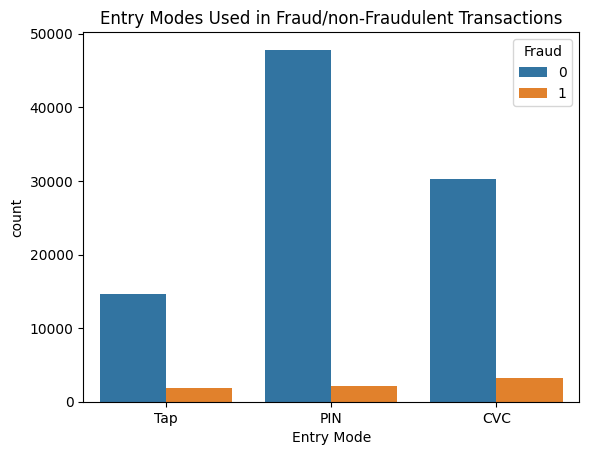

In [7]:
plt.title("Entry Modes Used in Fraud/non-Fraudulent Transactions")
sns.countplot(data = dataset, x = "Entry Mode",hue="Fraud")

<Axes: title={'center': 'Male/Female distribution in Fraudulent and Non-Fraudulent Transactions'}, xlabel='Gender', ylabel='count'>

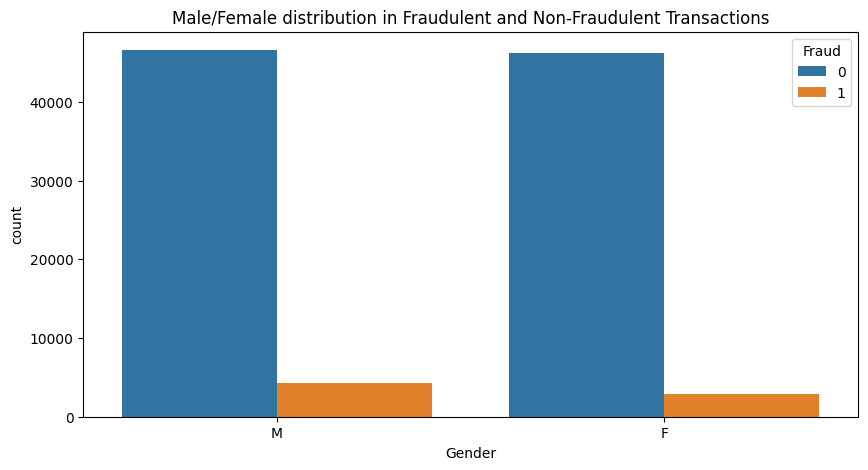

In [8]:
plt.figure(figsize=(10,5))
plt.title("Male/Female distribution in Fraudulent and Non-Fraudulent Transactions")
sns.countplot(data = dataset, x = "Gender",hue="Fraud")

<Axes: title={'center': 'Entry Mode Often Used in Fraud Transactions'}, xlabel='count', ylabel='Entry Mode'>

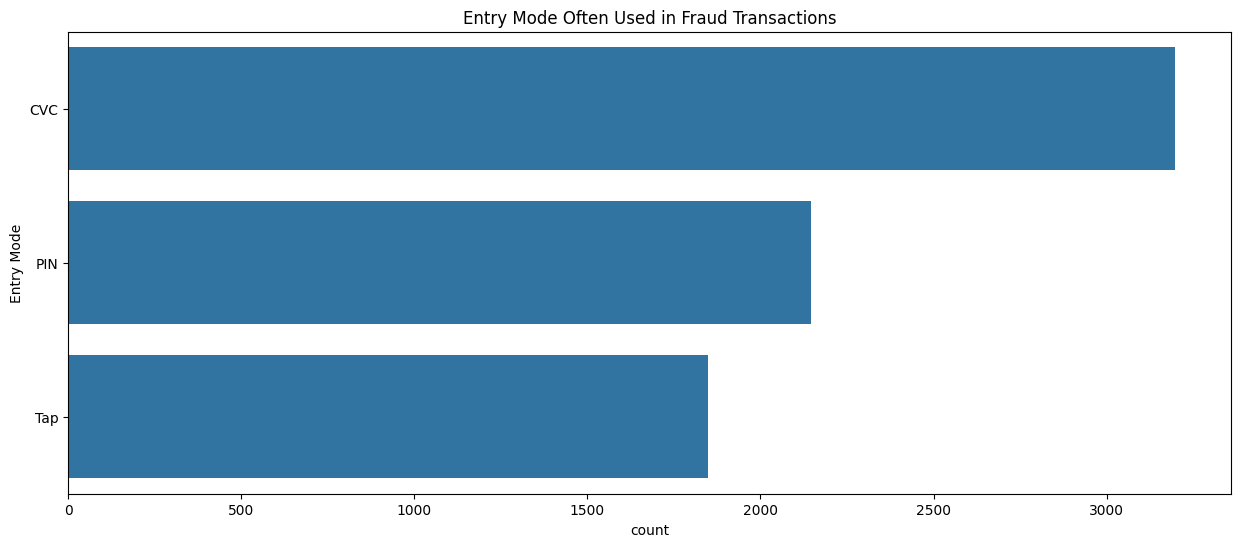

In [9]:
# What entry Mode is often Used in Fraud Transactions
plt.figure(figsize=(15,6))
df1 = dataset[dataset["Fraud"] == 1]

plt.title("Entry Mode Often Used in Fraud Transactions")
sns.countplot(df1["Entry Mode"])


<Axes: title={'center': 'Type of Card Often used in Fraudulent Transactions'}, xlabel='count', ylabel='Type of Card'>

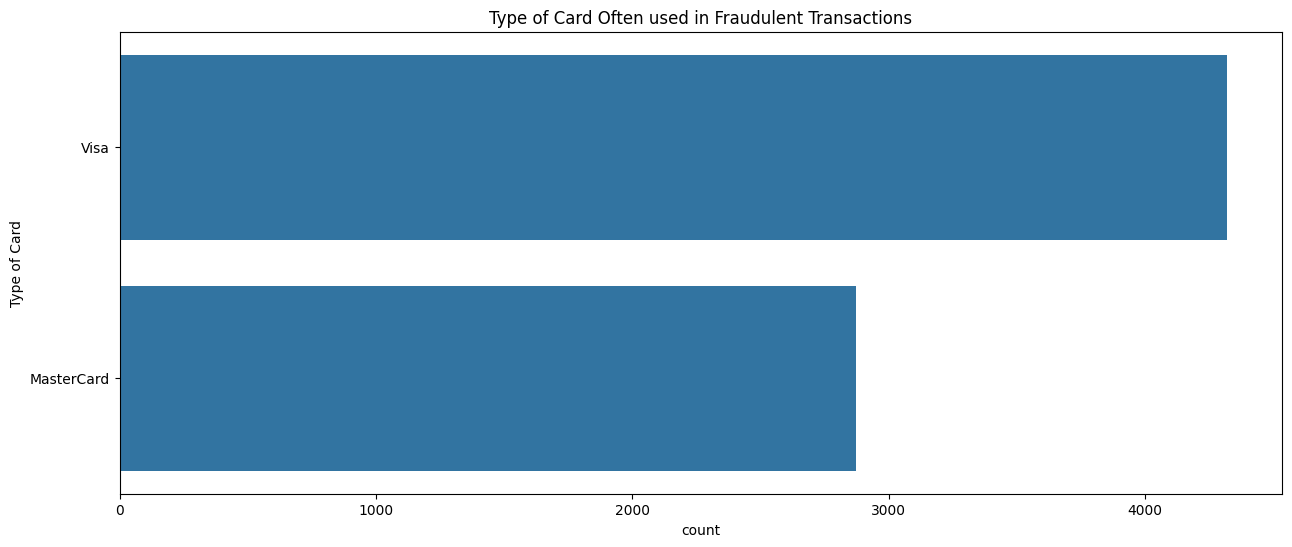

In [10]:
# What Type of Card is often Used in Fraud Transactions

plt.figure(figsize=(15,6))
df1 = dataset[dataset["Fraud"] == 1]

plt.title("Type of Card Often used in Fraudulent Transactions")
sns.countplot(df1["Type of Card"])

<Axes: title={'center': 'Merchant group with Most Fraudulent Transactions'}, xlabel='Merchant Group', ylabel='No of Fraud Transactions'>

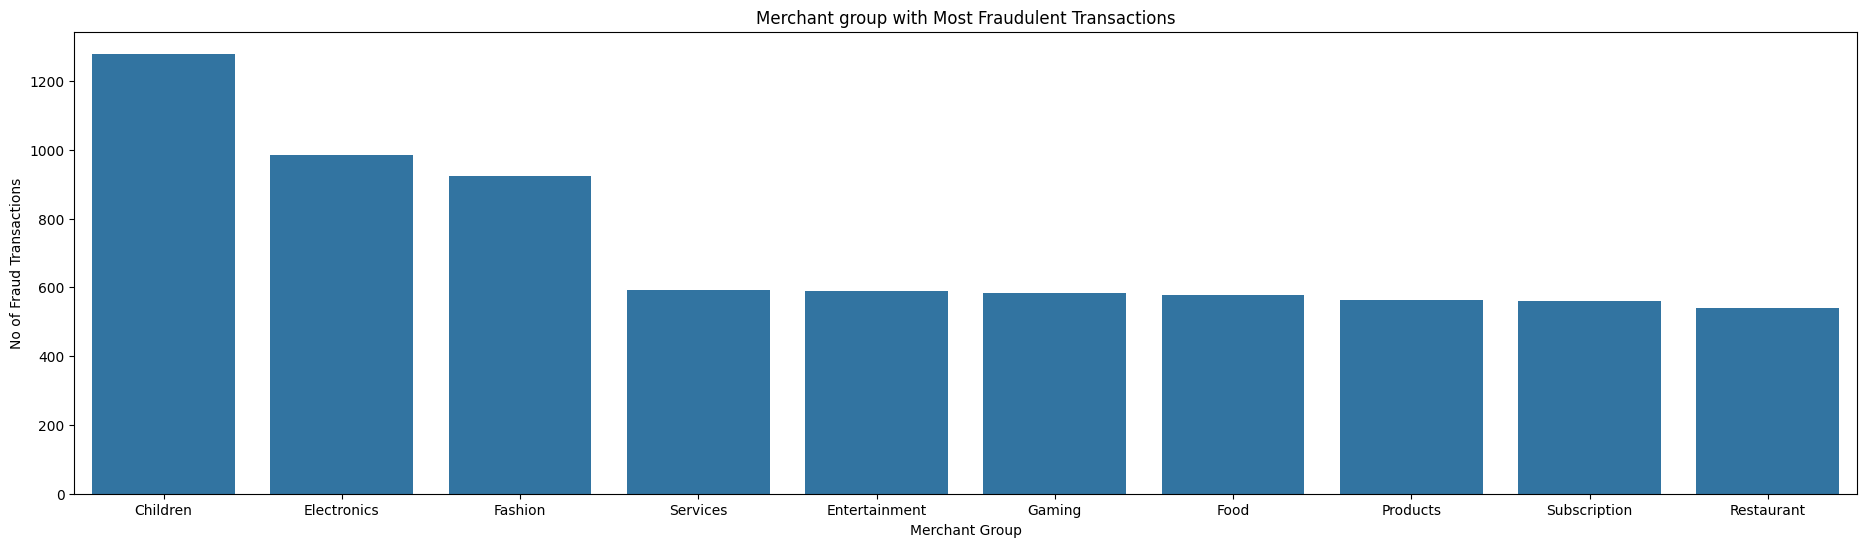

In [11]:
# Which merchant group has Large Number of Fraud Transactions 

plt.figure(figsize=(23,6))
df1 = dataset[dataset["Fraud"] == 1]

plt.title("Which Merchant Group has Large number of Fraudulent Transactions")
merchant_group = dict(df1["Merchant Group"].value_counts(),sorted=True)

del merchant_group["sorted"]
plt.title("Merchant group with Most Fraudulent Transactions")
plt.xlabel("Merchant Group")
plt.ylabel("No of Fraud Transactions")
sns.barplot(x=list(merchant_group.keys()),y=list(merchant_group.values()))


<Axes: title={'center': 'Bank with Most Fraud Transactions'}, xlabel='count', ylabel='Bank'>

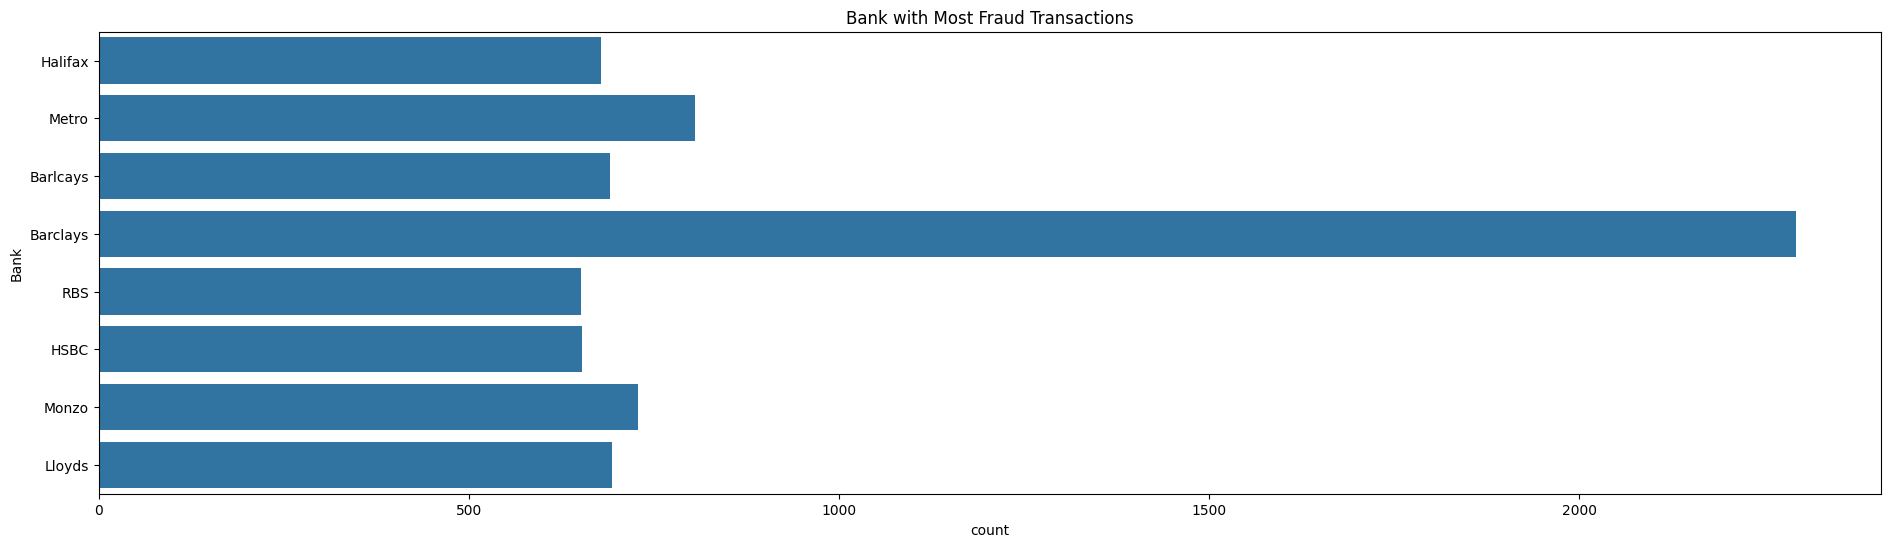

In [12]:
# Which Bank has the Most Fraud Cases

plt.figure(figsize=(23,6))
df1 = dataset[dataset["Fraud"] == 1]

plt.title("Bank with Most Fraud Transactions")
sns.countplot(df1["Bank"])
 

<Axes: title={'center': "Type of Transaction's Mostly used in Fraudulent transactions"}, xlabel='count', ylabel='Type of Transaction'>

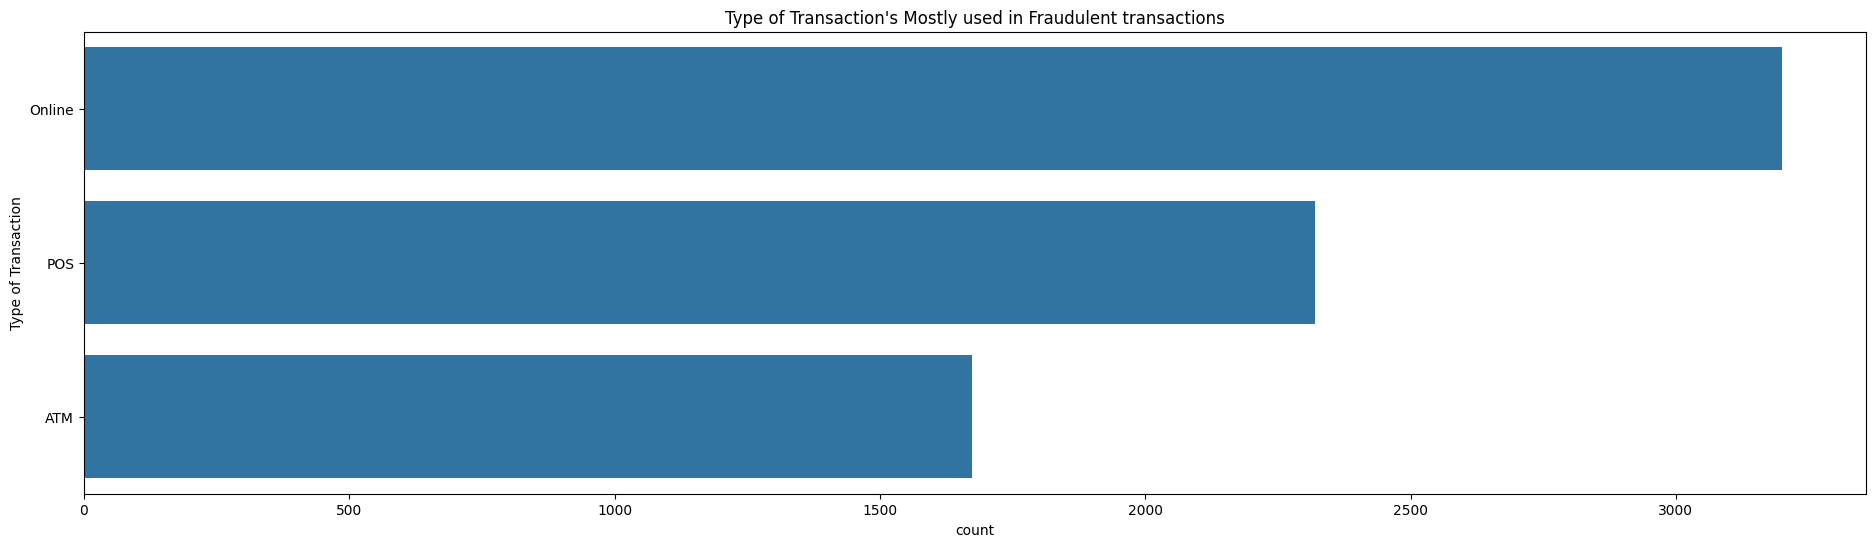

In [13]:
# Which Type Of Transaction is often Fraudulent

plt.figure(figsize=(23,6))
df1 = dataset[dataset["Fraud"] == 1]

plt.title("Type of Transaction's Mostly used in Fraudulent transactions")
sns.countplot(df1["Type of Transaction"])

In [14]:
dataset[["Amount (£)","Fraud"]].groupby("Fraud").agg(["mean","std","max"])

Amount (£)                   
             mean         std    max
Fraud                               
0      116.354034  124.047902  400.0
1       63.889739  103.578179  400.0

## **📊 Business Insights: Key Drivers of Fraudulent Transactions**

Based on exploratory data analysis, the following risk patterns were identified:

### 1️⃣ Bank-Level Exposure
Transactions associated with **Barclays Bank** show a relatively higher concentration of fraudulent activity, indicating potential exposure differences across issuing institutions.

### 2️⃣ Merchant Category Risk
The **Children Merchant Group** exhibits a disproportionately higher fraud incidence, suggesting that certain merchant segments may present elevated fraud vulnerability.

### 3️⃣ Transaction Channel Risk
**Online transactions** demonstrate a significantly higher fraud rate compared to other transaction types, reinforcing the increased risk associated with card-not-present environments.

### 4️⃣ Entry Mode Risk Indicator
Transactions processed using **CVC entry mode** are more frequently linked to fraudulent cases, indicating elevated risk in manual authentication scenarios.

### 5️⃣ Card Type Distribution
Fraud occurrences are more common among **Visa card transactions** within this dataset, which may reflect usage volume or exposure differences.

### 6️⃣ Transaction Amount Pattern
Fraudulent transactions tend to occur more frequently at **lower transaction amounts**, potentially reflecting fraudsters’ strategy to avoid detection through small-value testing transactions.

In [15]:
# Firstly we will drop (Transaction ID	Date, Day of Week, Time) these columns

dataset.drop(columns=["Transaction ID","Date"] , inplace = True)

dataset.head()

,Day of Week,Time,Type of Card,Entry Mode,Amount (£),Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,Wednesday,19,Visa,Tap,5.0,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,Wednesday,17,MasterCard,PIN,288.0,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,Wednesday,14,Visa,Tap,5.0,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,Tuesday,14,Visa,Tap,28.0,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,Tuesday,23,Visa,CVC,91.0,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [16]:
# Selecting all the categorical columns 

cat_columns = list(dataset.iloc[:,[0,1,2,3,5,6,7,8,9,10,12]].columns)


In [17]:
# Using Ordinal Encoder to Encode Categorical Columns
from sklearn.preprocessing import OrdinalEncoder

encoder_ = OrdinalEncoder()

dataset[cat_columns] = encoder_.fit_transform(dataset[cat_columns])

dataset.head()

,Day of Week,Time,Type of Card,Entry Mode,Amount (£),Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,3.0,19.0,1.0,2.0,5.0,2.0,2.0,4.0,4.0,4.0,1.0,25.2,7.0,0
1,3.0,17.0,0.0,1.0,288.0,2.0,8.0,3.0,3.0,3.0,0.0,49.6,4.0,0
2,3.0,14.0,1.0,2.0,5.0,2.0,7.0,1.0,1.0,1.0,0.0,42.2,0.0,0
3,2.0,14.0,1.0,2.0,28.0,2.0,2.0,4.0,1.0,4.0,0.0,51.0,0.0,0
4,2.0,23.0,1.0,0.0,91.0,1.0,1.0,3.0,3.0,4.0,1.0,38.0,3.0,1


## **🤖 Modeling Approach**

To predict fraudulent transactions, two supervised machine learning models were implemented:

1️⃣ **Logistic Regression**  
A baseline linear model used to establish a benchmark for classification performance and interpretability.

2️⃣ **Random Forest Classifier**  
An ensemble tree-based model designed to capture non-linear relationships and complex feature interactions within the data.

---

## 📊 Evaluation Strategy

Model performance was assessed using multiple classification metrics, including:

- **Precision**
- **Recall**
- **F1-Score**
- **ROC-AUC Score**

Given the nature of fraud detection, **Recall was prioritized**, as failing to detect fraudulent transactions (False Negatives) can result in significant financial loss.

To ensure model robustness and reduce overfitting risk:

- **K-Fold Cross-Validation** was performed using ROC-AUC as the scoring metric.


In [18]:
# firstly importing all the required libraries

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# for our model performance evaluation

from sklearn.metrics import roc_auc_score,roc_curve,classification_report, confusion_matrix

In [19]:
# Firstly we will select x and y variable an then split the data for testing and training 

x = dataset.drop(columns=["Fraud"])
y = dataset.Fraud

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.25)


Now Below we will Implement our First Model

In [20]:
log_reg = LogisticRegression(class_weight='balanced')

log_reg.fit(x_train,y_train)

# Now predicting the tet data 

predictions_ = log_reg.predict(x_test)

# Now evaluating our Model 
print(classification_report(y_test,predictions_))


# Get predicted probabilities (IMPORTANT: use predict_proba)
y_probs = log_reg.predict_proba(x_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", roc_auc)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     23159
           1       0.51      0.87      0.64      1836

    accuracy                           0.93     24995
   macro avg       0.75      0.90      0.80     24995
weighted avg       0.95      0.93      0.94     24995

ROC-AUC Score: 0.9526317356540901


f:\anaconda\envs\My_p_and_R\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
print("Cross Validation of logisitc Regression Model")
cv_scores = cross_val_score(log_reg, x, y, cv=5, scoring='roc_auc')

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

Cross Validation of logisitc Regression Model


f:\anaconda\envs\My_p_and_R\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
f:\anaconda\envs\My_p_and_R\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n

Cross-Validation ROC-AUC Scores: [0.95637868 0.96160061 0.95440215 0.95264772 0.95985601]
Mean ROC-AUC: 0.9569770338727347


f:\anaconda\envs\My_p_and_R\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


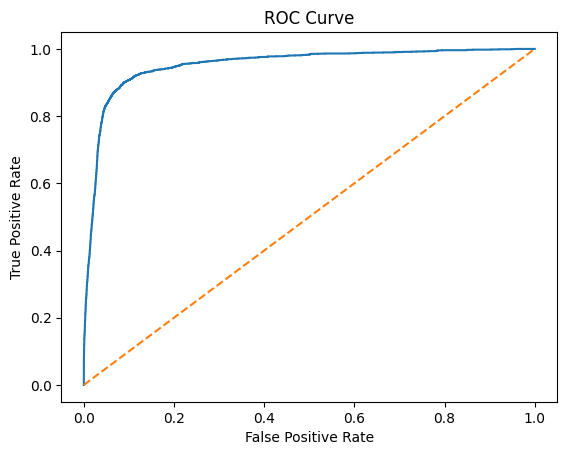

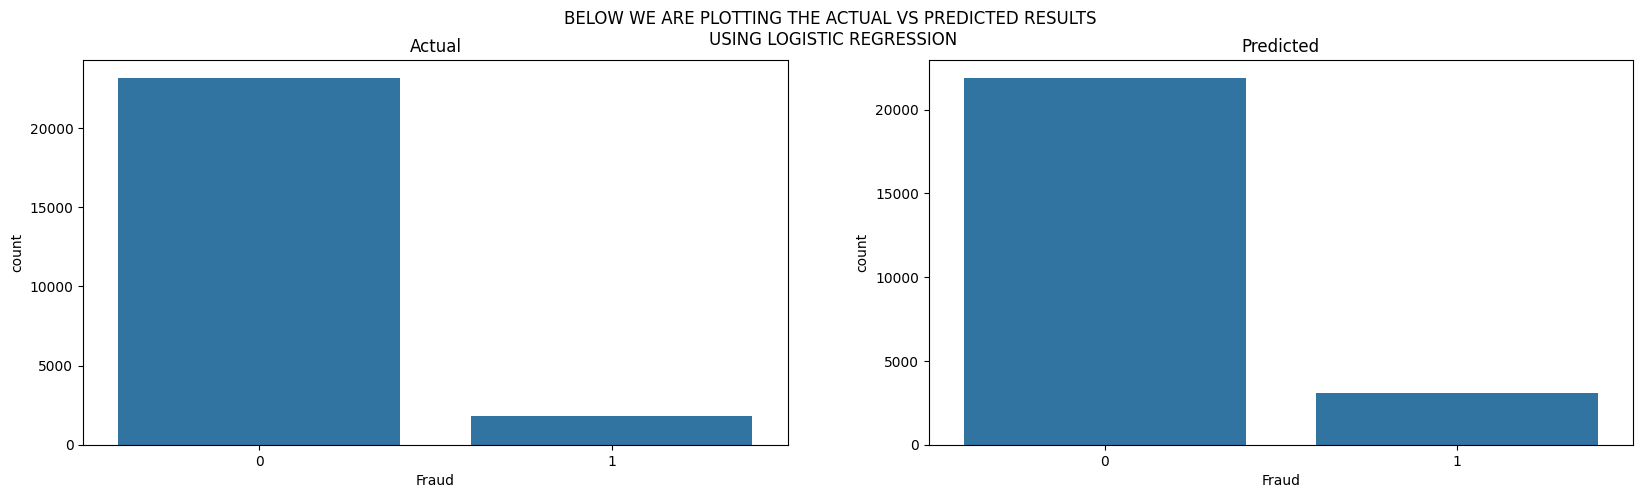

<Axes: title={'center': 'Confusion matrix for Logistic Regression Model'}>

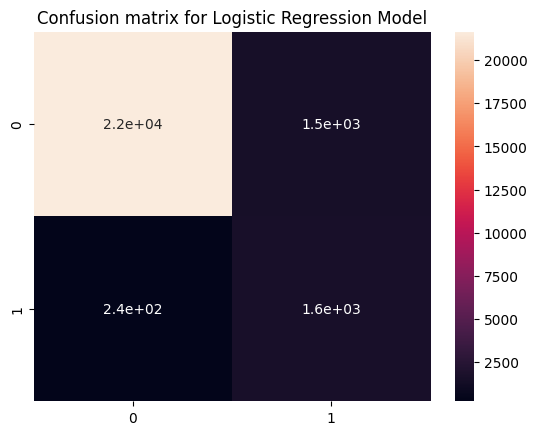

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Now lets see using a bar plot how much accurate our model is predicting as Looking at the accuracy the model is working Great!

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title("Actual")
sns.countplot(x=y_test)
plt.subplot(1,2,2)

plt.title("Predicted")
plt.xlabel("Fraud")
sns.countplot(x=predictions_)
plt.suptitle("Below we are Plotting the Actual vs Predicted Results \nUsing Logistic Regression\n\n".upper())
plt.show()


conf_matr = confusion_matrix(y_test,predictions_)

plt.title("Confusion matrix for Logistic Regression Model")
sns.heatmap(conf_matr,annot=True)




Looking on Above Analysis and Visualizations we can say that Our Model is Working Extremely well.

**Now Implementing Our second Model**

In [23]:
rf = RandomForestClassifier(class_weight='balanced')

rf.fit(x_train,y_train)

# Now predicting the tet data 

predictions_ = rf.predict(x_test)

# Now evaluating our Model 
print(classification_report(y_test,predictions_))


# Get predicted probabilities (IMPORTANT: use predict_proba)
y_probs = rf.predict_proba(x_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", roc_auc)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     23159
           1       0.98      0.82      0.89      1836

    accuracy                           0.99     24995
   macro avg       0.98      0.91      0.94     24995
weighted avg       0.99      0.99      0.98     24995

ROC-AUC Score: 0.9924725288784617


In [24]:
print("Cross Validation of RandomForest Model")
cv_scores = cross_val_score(rf, x, y, cv=5, scoring='roc_auc')

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

Cross Validation of RandomForest Model
Cross-Validation ROC-AUC Scores: [0.99049861 0.99315294 0.99302336 0.99165122 0.9934762 ]
Mean ROC-AUC: 0.9923604652750189


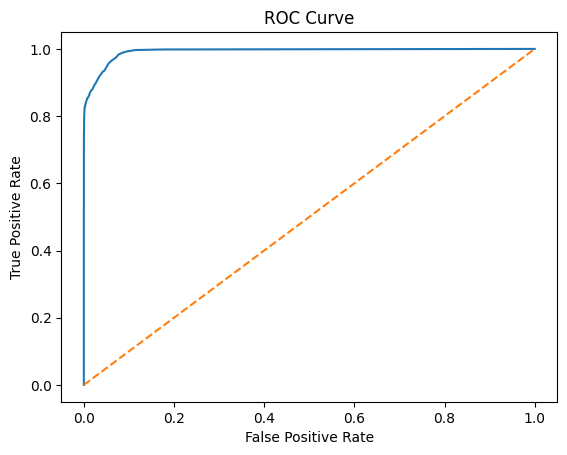

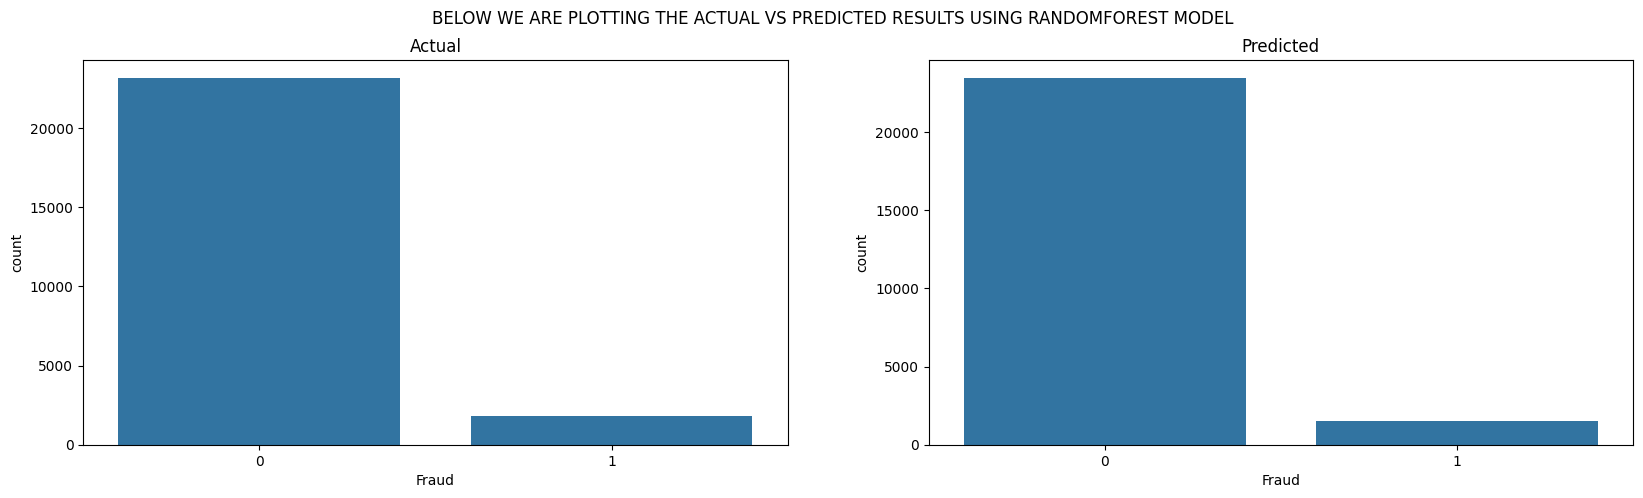

<Axes: title={'center': 'Confusion matrix for Random Forest Model'}>

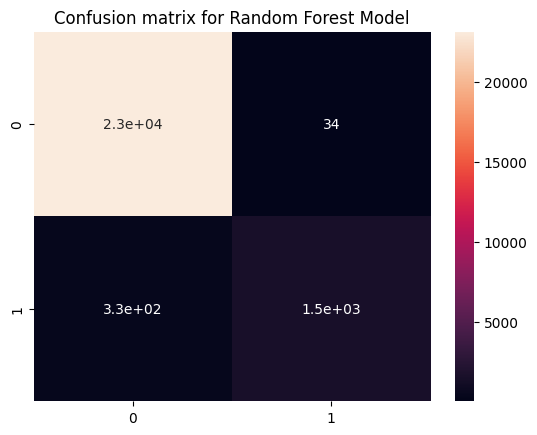

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
# Now lets ee using a bar plot how much accurate our model is predicting as Looking at the accuracy the model is working Great!

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title("Actual")
sns.countplot(x=y_test)
plt.subplot(1,2,2)

plt.title("Predicted")
plt.xlabel("Fraud")
sns.countplot(x=predictions_)


plt.suptitle("Below we are Plotting the Actual vs Predicted Results Using RandomForest Model".upper())


plt.show()


conf_matr = confusion_matrix(y_test,predictions_)

plt.title("Confusion matrix for Random Forest Model")
sns.heatmap(conf_matr,annot=True)

## **🏆 Final Model Selection**

Based on comparative evaluation using Recall and ROC-AUC metrics, the **Random Forest Classifier** was selected as the final model.  

It demonstrated superior ability to detect fraudulent transactions while maintaining balanced precision, making it the most suitable model for this credit fraud detection task.